Shape: (20000, 8)

Columns:
Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Age_Group', 'Employment_Status', 'Customer_Segment'],
      dtype='object')

Data Types:
Customer_ID           int64
Gender               object
Senior_Citizen        int64
Partner              object
Dependents           object
Age_Group            object
Employment_Status    object
Customer_Segment     object
dtype: object

First 5 Rows:


,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Age_Group,Employment_Status,Customer_Segment
0,1,Female,0,No,Yes,56-65,Employed,Premium
1,2,Male,1,Yes,Yes,36-45,Student,Standard
2,3,Male,0,Yes,Yes,26-35,Employed,Enterprise
3,4,Male,0,No,Yes,26-35,Employed,Standard
4,5,Female,0,No,Yes,36-45,Employed,Standard



Missing Values:
Customer_ID          0
Gender               0
Senior_Citizen       0
Partner              0
Dependents           0
Age_Group            0
Employment_Status    0
Customer_Segment     0
dtype: int64


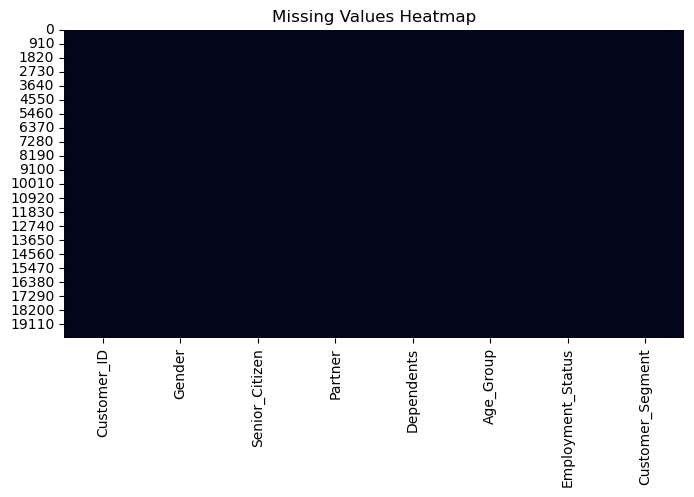

Duplicate Rows: 0


,Customer_ID,Senior_Citizen
count,20000.000000,20000.000000
mean,10000.500000,0.179850
std,5773.647028,0.384072
min,1.000000,0.000000
25%,5000.750000,0.000000
50%,10000.500000,0.000000
75%,15000.250000,0.000000
max,20000.000000,1.000000


,Gender,Partner,Dependents,Age_Group,Employment_Status,Customer_Segment
count,20000,20000,20000,20000,20000,20000
unique,3,2,2,6,5,4
top,Female,No,No,26-35,Employed,Standard
freq,9647,10429,11370,5737,11011,7908



Customer_ID
Unique Values: 20000

Gender
Unique Values: 3

Senior_Citizen
Unique Values: 2

Partner
Unique Values: 2

Dependents
Unique Values: 2

Age_Group
Unique Values: 6

Employment_Status
Unique Values: 5

Customer_Segment
Unique Values: 4


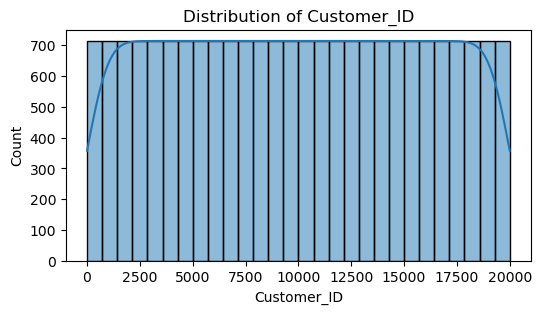

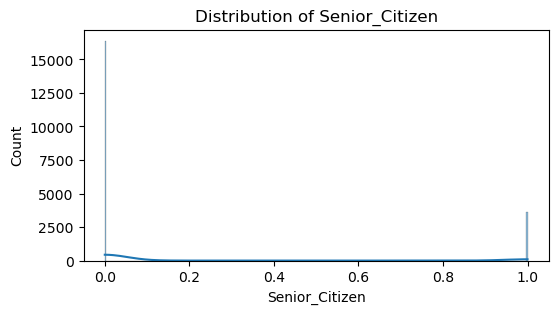

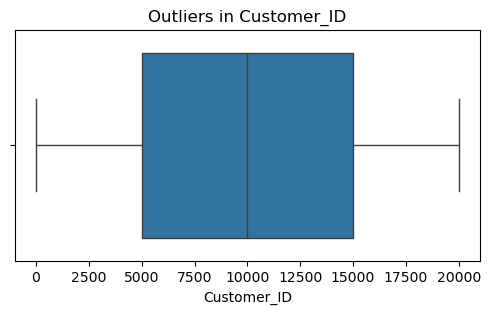

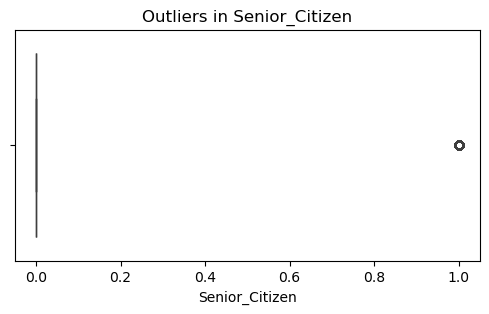

,Column,DataType,Nulls,Unique
0,Customer_ID,int64,0,20000
1,Gender,object,0,3
2,Senior_Citizen,int64,0,2
3,Partner,object,0,2
4,Dependents,object,0,2
5,Age_Group,object,0,6
6,Employment_Status,object,0,5
7,Customer_Segment,object,0,4



EDA Completed Successfully


In [2]:
#====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load file
df = pd.read_csv("Dim_Customer.csv")

# -------------------------
# Basic Information
# -------------------------
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

# -------------------------
# Missing Values
# -------------------------
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# -------------------------
# Duplicate Records
# -------------------------
print("Duplicate Rows:", df.duplicated().sum())

# -------------------------
# Statistical Summary
# -------------------------
display(df.describe())

display(df.describe(include='object'))

# -------------------------
# Unique Values
# -------------------------
for col in df.columns:
    print(f"\n{col}")
    print("Unique Values:", df[col].nunique())

# -------------------------
# Numerical Columns
# -------------------------
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# -------------------------
# Boxplots (Outliers)
# -------------------------
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# -------------------------
# Categorical Columns
# -------------------------

# -------------------------


# -------------------------
# Data Quality Report
# -------------------------
report = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.values,
    "Nulls": df.isnull().sum().values,
    "Unique": df.nunique().values
})

display(report)

print("\nEDA Completed Successfully")

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load file
df = pd.read_csv("Dim_Customer.csv")

# Select numeric columns only
numeric_df = df.select_dtypes(include=np.number)

# Remove ID columns
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains('id', case=False)]

# Check if enough numeric columns exist
if numeric_df.shape[1] > 1:

    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=0.5,
        square=True
    )

    plt.title("Dim Customer Correlation Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("No sufficient numerical columns available for correlation analysis.")

No sufficient numerical columns available for correlation analysis.


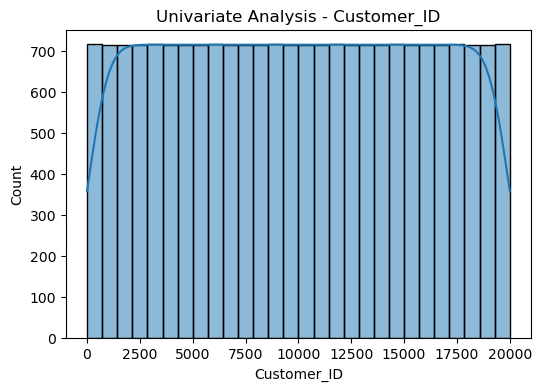

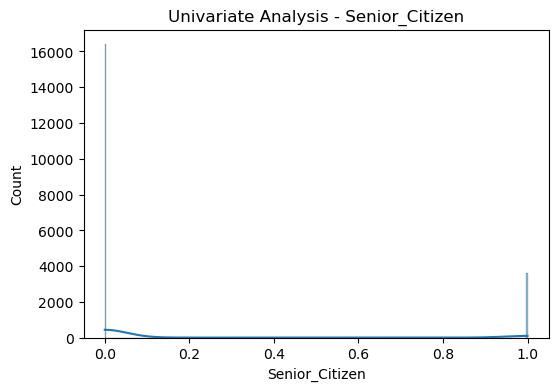

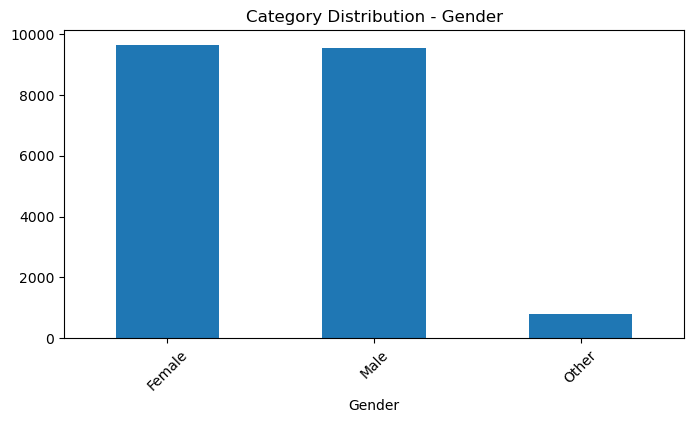

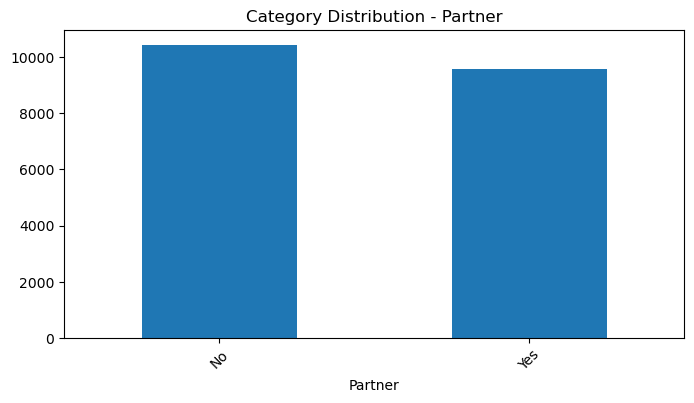

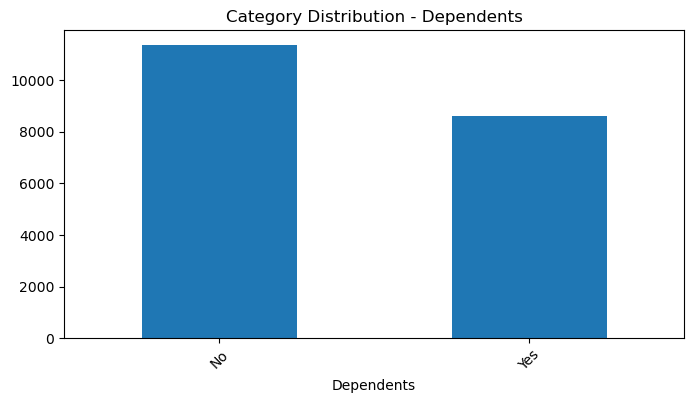

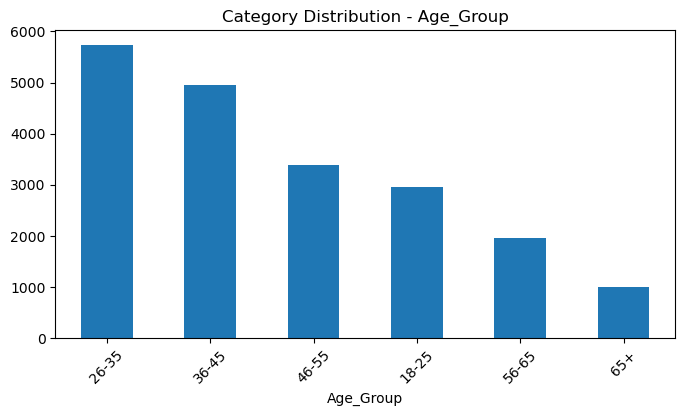

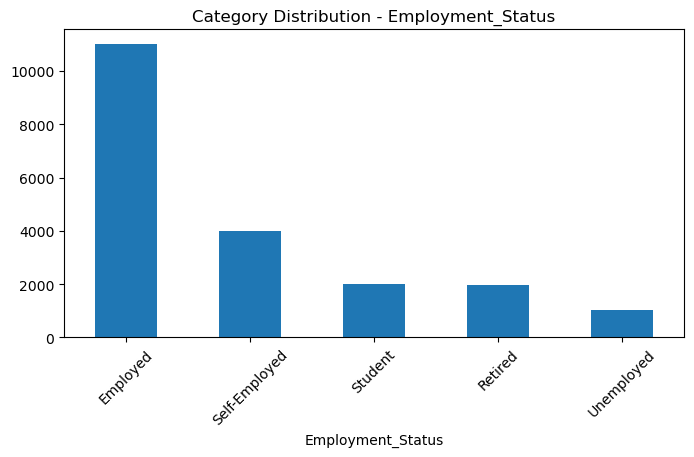

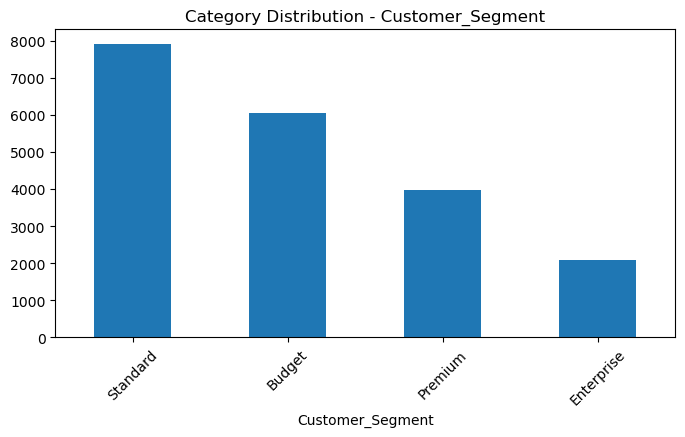

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dim_Customer.csv")

# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Univariate Analysis - {col}')
    plt.show()

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Category Distribution - {col}')
    plt.xticks(rotation=45)
    plt.show()

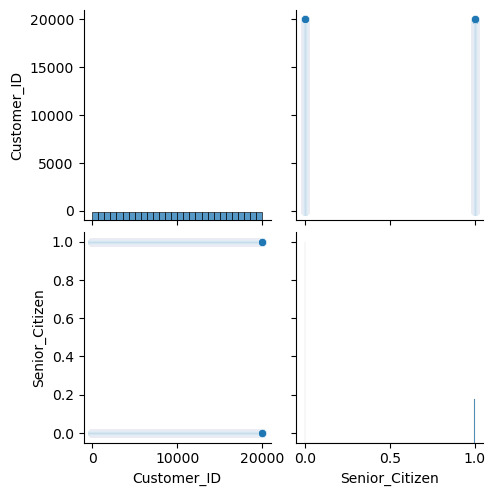

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

if len(num_cols) >= 2:
    sns.pairplot(df[num_cols])
    plt.show()

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Customer.csv")

# Remove ID columns
num_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns
            if 'id' not in col.lower()]

if len(num_cols) >= 2:
    sns.pairplot(df[num_cols])
    plt.show()
else:
    print("Not enough meaningful numerical columns for bivariate analysis.")

Not enough meaningful numerical columns for bivariate analysis.


In [8]:
print(df.columns)

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Age_Group', 'Employment_Status', 'Customer_Segment'],
      dtype='object')


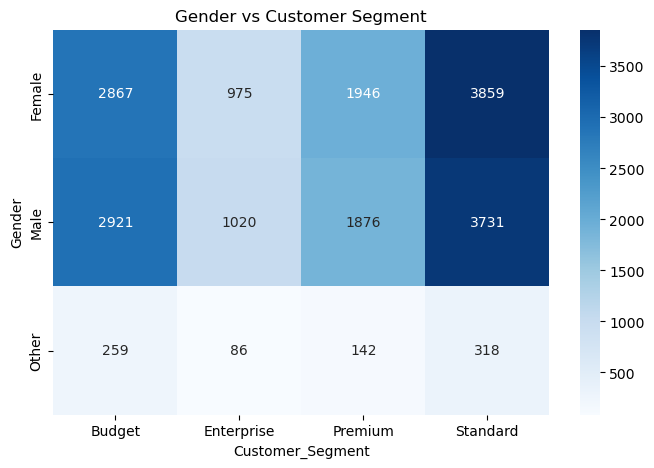

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Customer.csv")

cross_tab = pd.crosstab(df['Gender'], df['Customer_Segment'])

plt.figure(figsize=(8,5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Gender vs Customer Segment')
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dim_Contract.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.head()

Shape: (6, 5)

Columns:
Index(['Contract_ID', 'Contract_Type', 'Contract_Duration_Months',
       'Auto_Renewal', 'Early_Termination_Fee_INR'],
      dtype='object')

Data Types:
Contract_ID                   int64
Contract_Type                object
Contract_Duration_Months      int64
Auto_Renewal                 object
Early_Termination_Fee_INR     int64
dtype: object


,Contract_ID,Contract_Type,Contract_Duration_Months,Auto_Renewal,Early_Termination_Fee_INR
0,1,Month-to-Month,1,No,0
1,2,Month-to-Month,1,Yes,0
2,3,One Year,12,No,500
3,4,One Year,12,Yes,500
4,5,Two Year,24,No,1000


Contract_ID                  0
Contract_Type                0
Contract_Duration_Months     0
Auto_Renewal                 0
Early_Termination_Fee_INR    0
dtype: int64


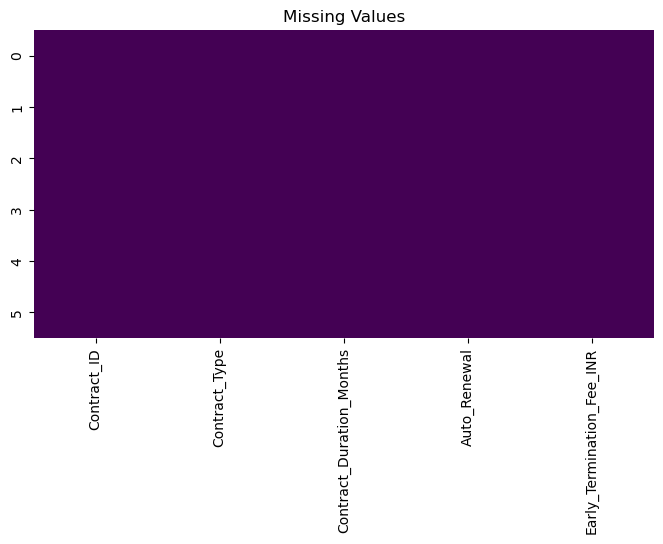

In [11]:
print(df.isnull().sum())

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df.describe(include='all')

,Contract_ID,Contract_Type,Contract_Duration_Months,Auto_Renewal,Early_Termination_Fee_INR
count,6.000000,6,6.000000,6,6.000000
unique,NaN,3,NaN,2,NaN
top,NaN,Month-to-Month,NaN,No,NaN
freq,NaN,2,NaN,3,NaN
mean,3.500000,NaN,12.333333,NaN,500.000000
std,1.870829,NaN,10.289153,NaN,447.213595
min,1.000000,NaN,1.000000,NaN,0.000000
25%,2.250000,NaN,3.750000,NaN,125.000000
50%,3.500000,NaN,12.000000,NaN,500.000000
75%,4.750000,NaN,21.000000,NaN,875.000000


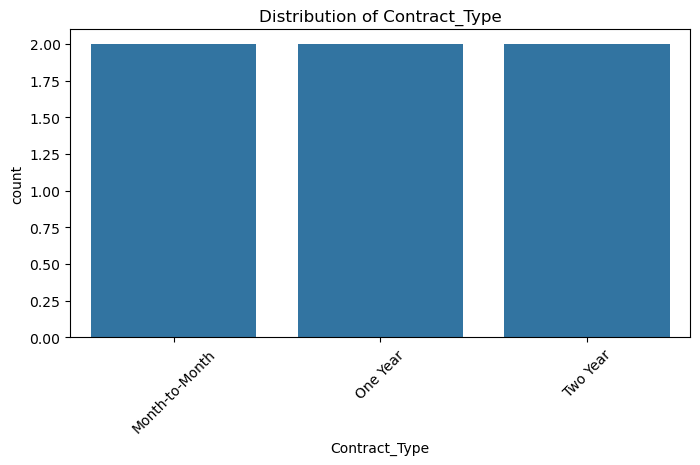

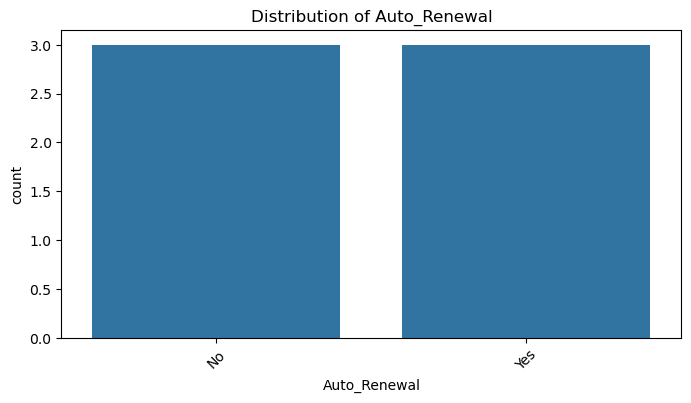

In [14]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [15]:
print(df.columns)

Index(['Contract_ID', 'Contract_Type', 'Contract_Duration_Months',
       'Auto_Renewal', 'Early_Termination_Fee_INR'],
      dtype='object')


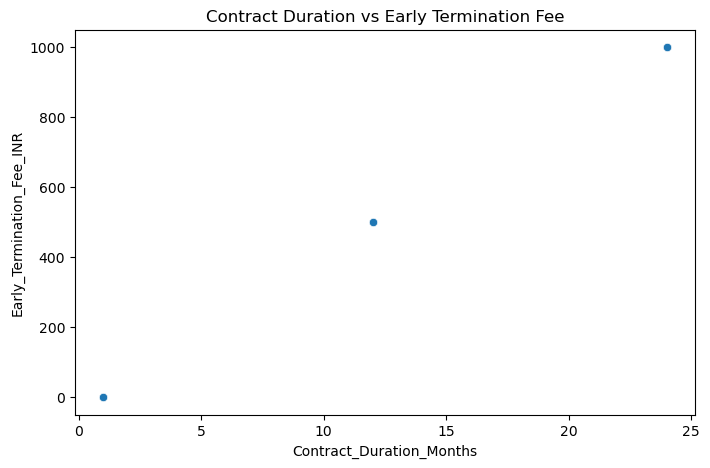

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Contract_Duration_Months',
    y='Early_Termination_Fee_INR'
)

plt.title('Contract Duration vs Early Termination Fee')
plt.show()

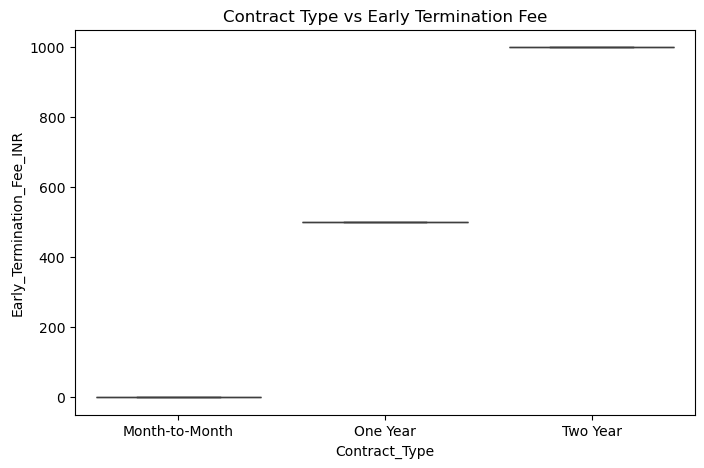

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Contract_Type',
    y='Early_Termination_Fee_INR'
)

plt.title('Contract Type vs Early Termination Fee')
plt.show()

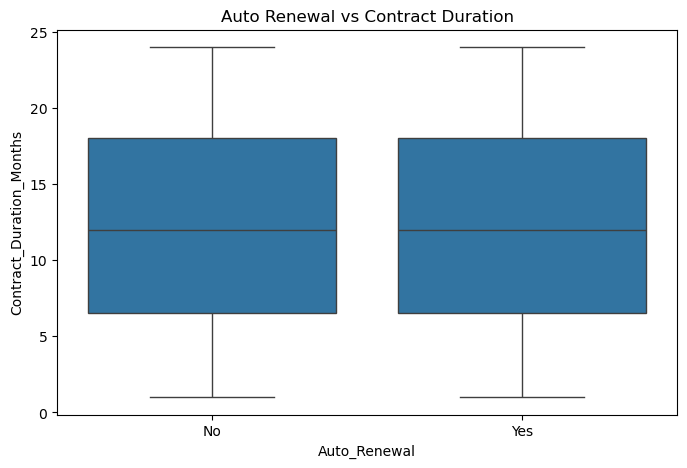

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Auto_Renewal',
    y='Contract_Duration_Months'
)

plt.title('Auto Renewal vs Contract Duration')
plt.show()

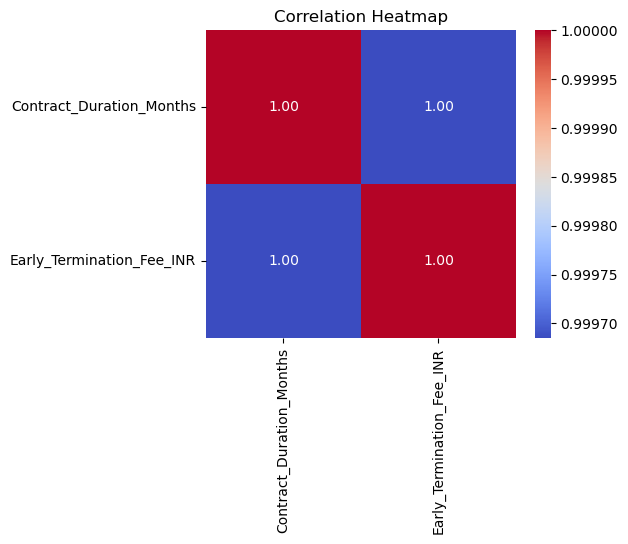

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Contract_Duration_Months',
           'Early_Termination_Fee_INR']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [20]:
import pandas as pd

df = pd.read_csv("Dim_Plan.csv")

print("Shape:", df.shape)
print(df.info())
df.head()

Shape: (10, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Plan_ID            10 non-null     int64 
 1   Plan_Name          10 non-null     object
 2   Monthly_Fee_INR    10 non-null     int64 
 3   Data_Limit_GB      10 non-null     int64 
 4   Promotional_Offer  5 non-null      object
 5   Bundle_Type        10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes
None


,Plan_ID,Plan_Name,Monthly_Fee_INR,Data_Limit_GB,Promotional_Offer,Bundle_Type
0,1,Starter ADSL,249,5,NaN,Broadband
1,2,Basic 10GB,299,10,NaN,Broadband
2,3,Standard 50GB,499,50,10% Off,Broadband
3,4,Standard Cable,549,50,NaN,Cable+Internet
4,5,Mobile Basic,199,5,Free OTT 3M,Mobile


Plan_ID              0
Plan_Name            0
Monthly_Fee_INR      0
Data_Limit_GB        0
Promotional_Offer    5
Bundle_Type          0
dtype: int64


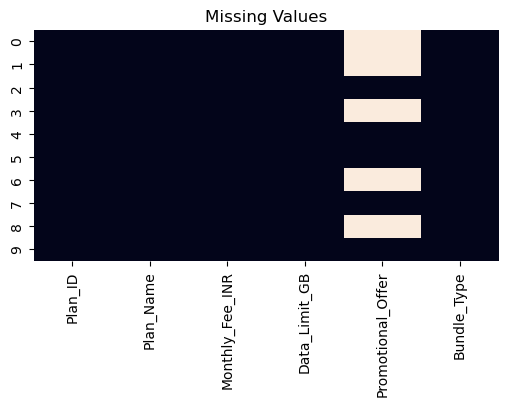

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())

plt.figure(figsize=(6,3))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [23]:
df.describe()

,Plan_ID,Monthly_Fee_INR,Data_Limit_GB
count,10.00000,10.000000,10.000000
mean,5.50000,609.000000,178.900000
std,3.02765,399.165797,324.208249
min,1.00000,199.000000,5.000000
25%,3.25000,324.000000,12.500000
50%,5.50000,524.000000,50.000000
75%,7.75000,749.000000,87.500000
max,10.00000,1499.000000,999.000000


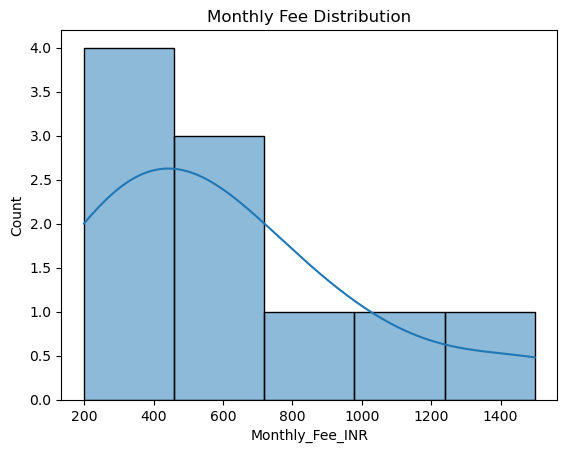

In [24]:
sns.histplot(df['Monthly_Fee_INR'], kde=True)
plt.title("Monthly Fee Distribution")
plt.show()

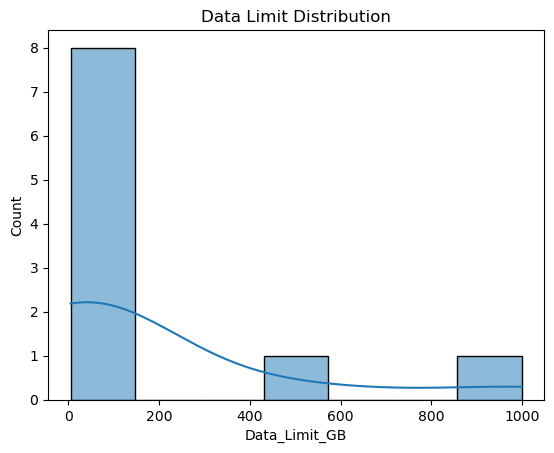

In [25]:
sns.histplot(df['Data_Limit_GB'], kde=True)
plt.title("Data Limit Distribution")
plt.show()

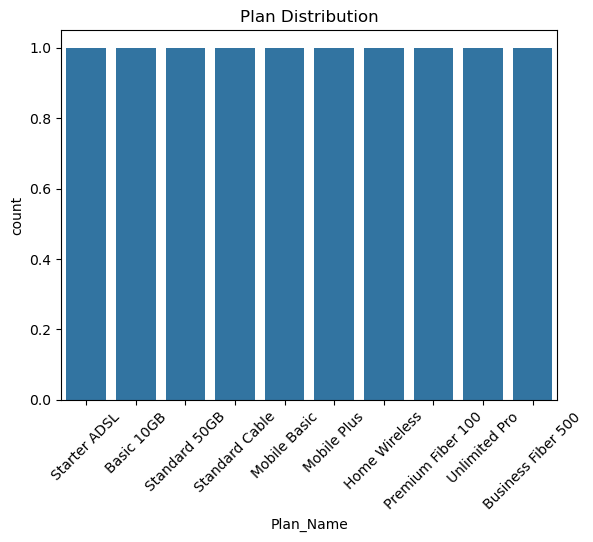

In [26]:
sns.countplot(data=df, x='Plan_Name')
plt.xticks(rotation=45)
plt.title("Plan Distribution")
plt.show()

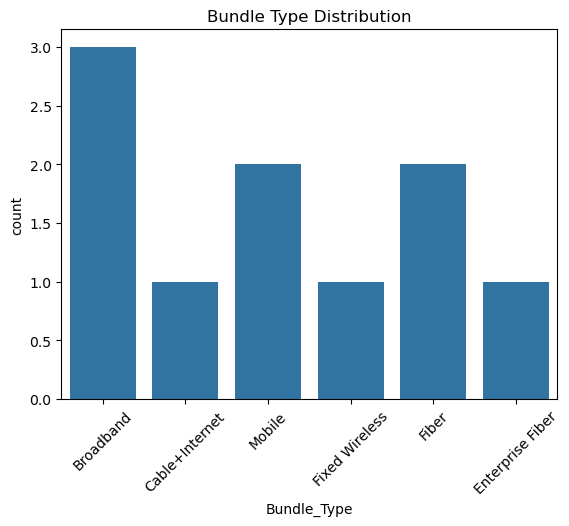

In [27]:
sns.countplot(data=df, x='Bundle_Type')
plt.xticks(rotation=45)
plt.title("Bundle Type Distribution")
plt.show()

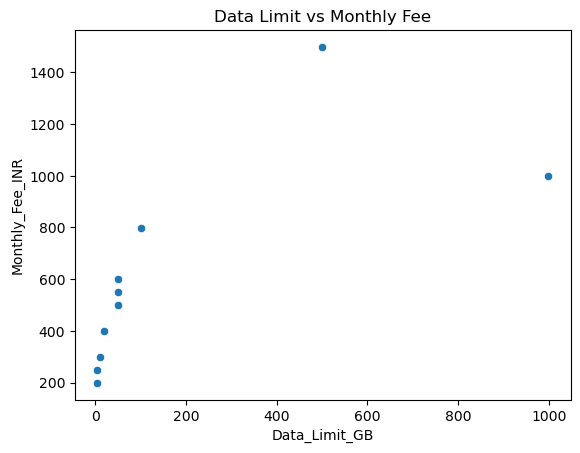

In [28]:
sns.scatterplot(
    data=df,
    x='Data_Limit_GB',
    y='Monthly_Fee_INR'
)

plt.title("Data Limit vs Monthly Fee")
plt.show()

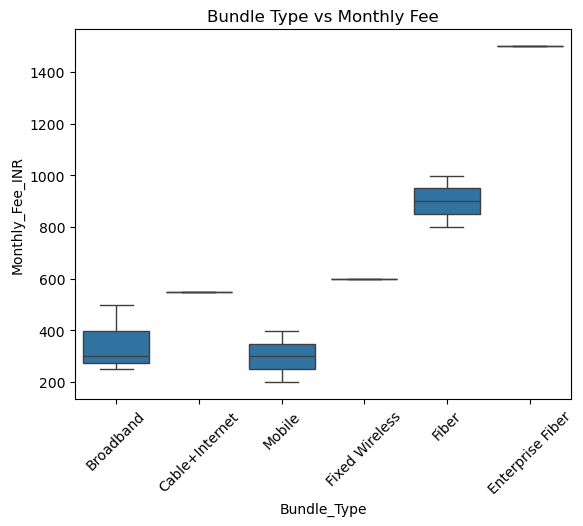

In [29]:
sns.boxplot(
    data=df,
    x='Bundle_Type',
    y='Monthly_Fee_INR'
)

plt.xticks(rotation=45)
plt.title("Bundle Type vs Monthly Fee")
plt.show()

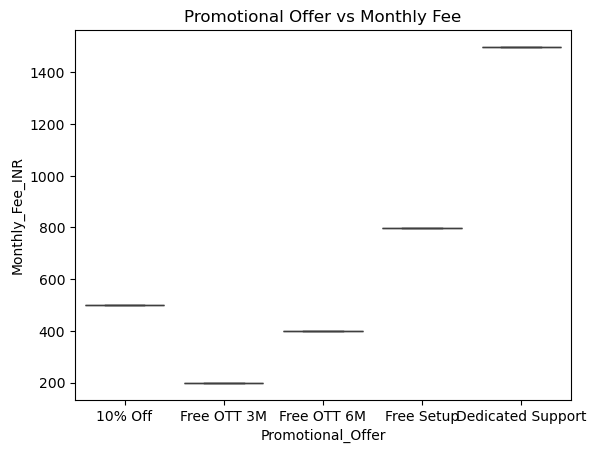

In [30]:
sns.boxplot(
    data=df,
    x='Promotional_Offer',
    y='Monthly_Fee_INR'
)

plt.title("Promotional Offer vs Monthly Fee")
plt.show()

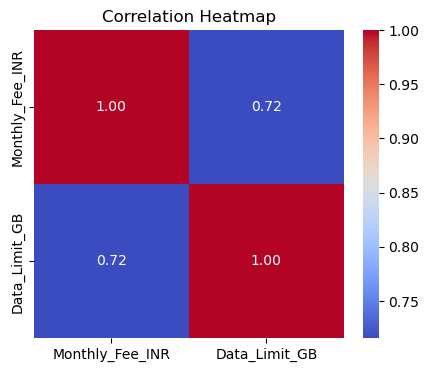

In [31]:
corr = df[['Monthly_Fee_INR','Data_Limit_GB']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [32]:
report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Null Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

report

,Column,Data Type,Null Values,Unique Values
Plan_ID,Plan_ID,int64,0,10
Plan_Name,Plan_Name,object,0,10
Monthly_Fee_INR,Monthly_Fee_INR,int64,0,10
Data_Limit_GB,Data_Limit_GB,int64,0,7
Promotional_Offer,Promotional_Offer,object,5,5
Bundle_Type,Bundle_Type,object,0,6


In [35]:
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values,
    'Null %': null_percent.values,
    'Unique Values': df.nunique().values
})

report

,Column,Data Type,Null Values,Null %,Unique Values
0,Plan_ID,int64,0,0.0,10
1,Plan_Name,object,0,0.0,10
2,Monthly_Fee_INR,int64,0,0.0,10
3,Data_Limit_GB,int64,0,0.0,7
4,Promotional_Offer,object,5,50.0,5
5,Bundle_Type,object,0,0.0,6


In [36]:
import pandas as pd

df = pd.read_csv("Dim_Payment.csv")

df.head()

,Payment_ID,Payment_Method,Paperless_Billing,Billing_Cycle
0,1,UPI,Yes,Monthly
1,2,Net Banking,Yes,Monthly
2,3,Credit Card,Yes,Monthly
3,4,Debit Card,Yes,Monthly
4,5,Cash,No,Monthly


In [38]:
print(df.shape)
print(df.columns)

(8, 4)
Index(['Payment_ID', 'Payment_Method', 'Paperless_Billing', 'Billing_Cycle'], dtype='object')


In [39]:
print(df.columns)

Index(['Payment_ID', 'Payment_Method', 'Paperless_Billing', 'Billing_Cycle'], dtype='object')


Payment_ID           0
Payment_Method       0
Paperless_Billing    0
Billing_Cycle        0
dtype: int64


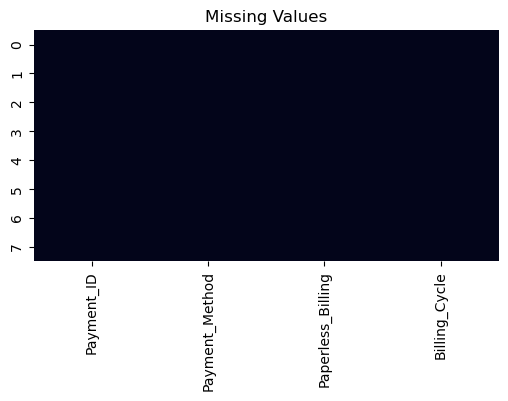

In [40]:
print(df.isnull().sum())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [41]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


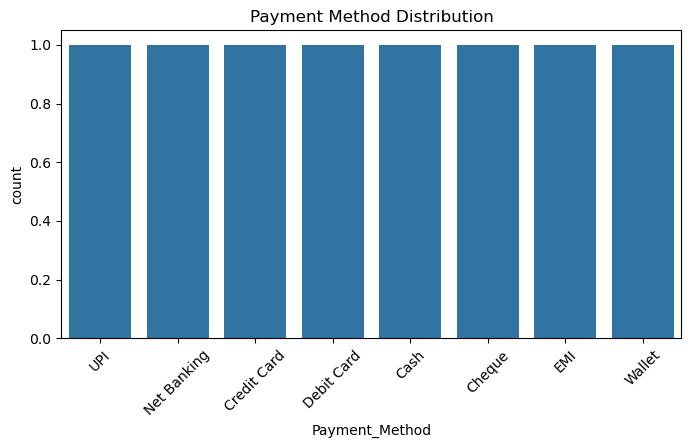

In [42]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Payment_Method')
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

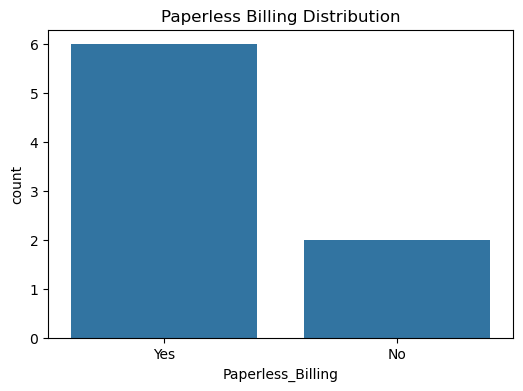

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Paperless_Billing')
plt.title("Paperless Billing Distribution")
plt.show()

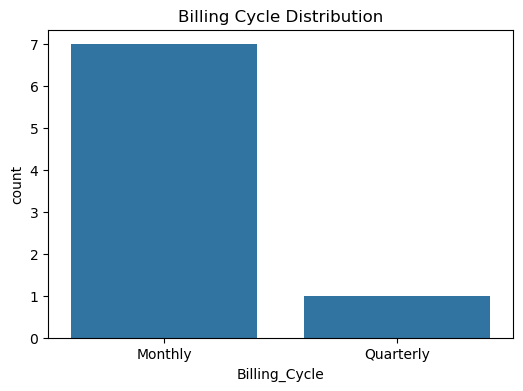

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Billing_Cycle')
plt.title("Billing Cycle Distribution")
plt.show()

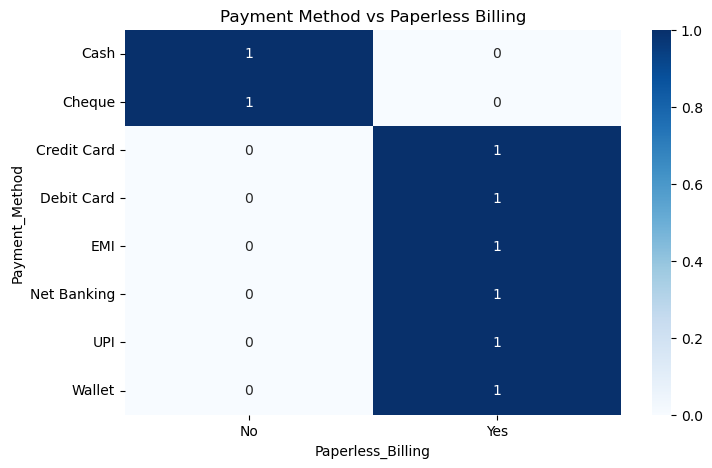

In [45]:
cross_tab = pd.crosstab(
    df['Payment_Method'],
    df['Paperless_Billing']
)

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Payment Method vs Paperless Billing")
plt.show()

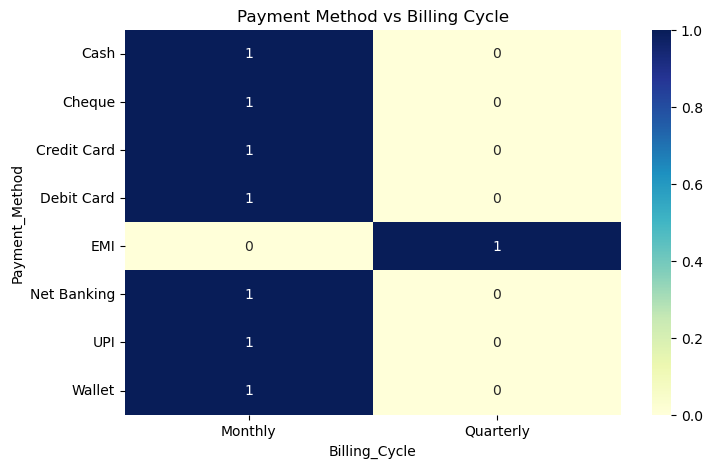

In [46]:
cross_tab = pd.crosstab(
    df['Payment_Method'],
    df['Billing_Cycle']
)

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Payment Method vs Billing Cycle")
plt.show()

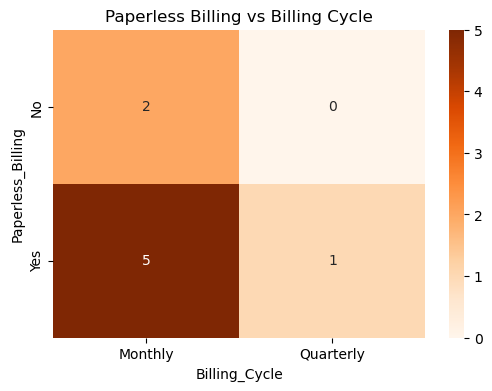

In [47]:
cross_tab = pd.crosstab(
    df['Paperless_Billing'],
    df['Billing_Cycle']
)

plt.figure(figsize=(6,4))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Paperless Billing vs Billing Cycle")
plt.show()

In [48]:
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values,
    'Null %': null_percent.values,
    'Unique Values': df.nunique().values
})

report

,Column,Data Type,Null Values,Null %,Unique Values
0,Payment_ID,int64,0,0.0,8
1,Payment_Method,object,0,0.0,8
2,Paperless_Billing,object,0,0.0,2
3,Billing_Cycle,object,0,0.0,2


In [49]:
import pandas as pd

df = pd.read_csv("Dim_Internet_Service.csv")

print(df.shape)
print(df.columns)

df.head()

(6, 7)
Index(['Internet_Service_ID', 'Internet_Type', 'Download_Speed_Mbps',
       'Streaming_Service', 'Online_Security', 'Device_Protection',
       'Tech_Support'],
      dtype='object')


,Internet_Service_ID,Internet_Type,Download_Speed_Mbps,Streaming_Service,Online_Security,Device_Protection,Tech_Support
0,1,Fiber Optic,300,Yes,Yes,Yes,Yes
1,2,Fiber Optic,1000,Yes,Yes,Yes,Yes
2,3,DSL,25,No,No,No,No
3,4,DSL,50,Yes,No,No,No
4,5,Cable,150,Yes,Yes,No,No


In [50]:
print(df.columns)

Index(['Internet_Service_ID', 'Internet_Type', 'Download_Speed_Mbps',
       'Streaming_Service', 'Online_Security', 'Device_Protection',
       'Tech_Support'],
      dtype='object')


Internet_Service_ID    0
Internet_Type          0
Download_Speed_Mbps    0
Streaming_Service      0
Online_Security        0
Device_Protection      0
Tech_Support           0
dtype: int64


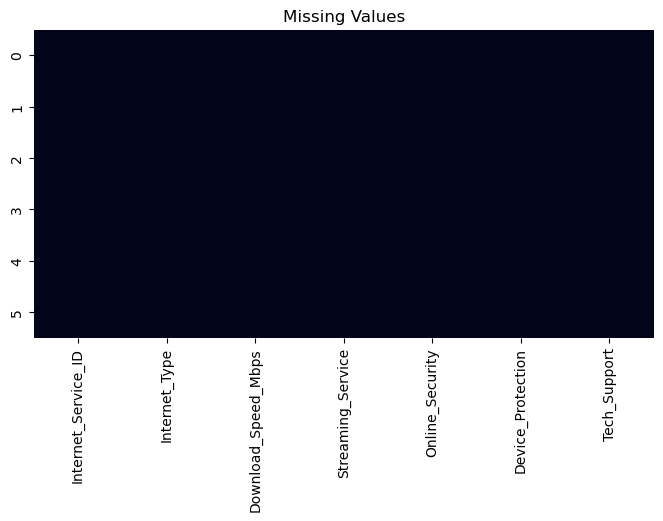

In [51]:
print(df.isnull().sum())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [53]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


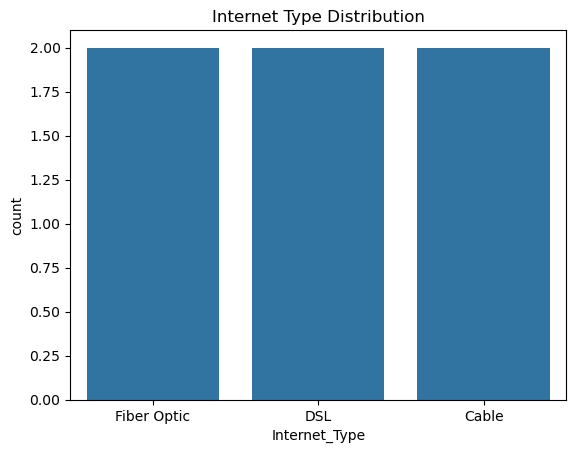

In [54]:
sns.countplot(data=df, x='Internet_Type')
plt.title("Internet Type Distribution")
plt.show()

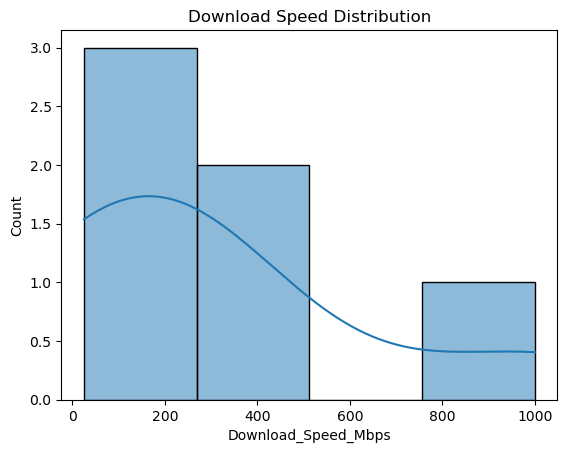

In [55]:
sns.histplot(df['Download_Speed_Mbps'], kde=True)
plt.title("Download Speed Distribution")
plt.show()

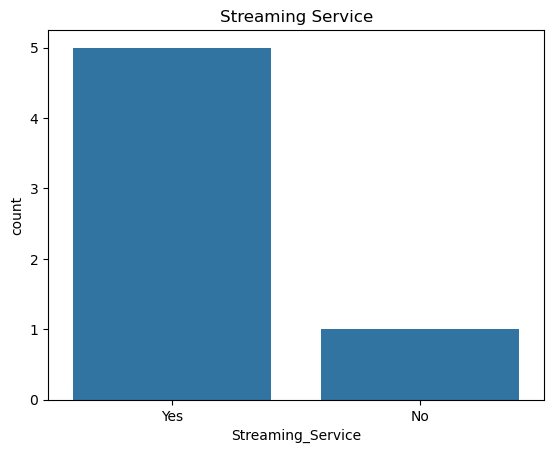

In [56]:
sns.countplot(data=df, x='Streaming_Service')
plt.title("Streaming Service")
plt.show()

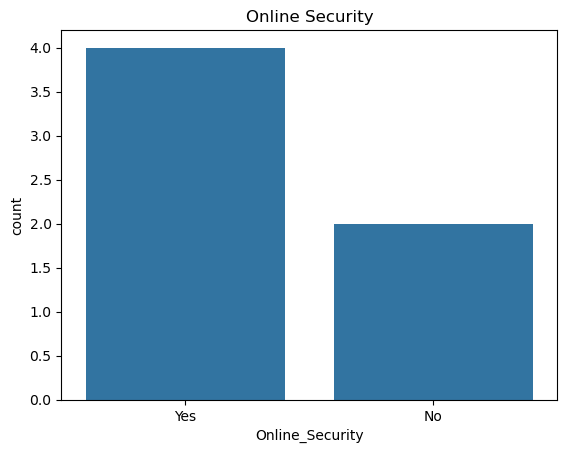

In [57]:
sns.countplot(data=df, x='Online_Security')
plt.title("Online Security")
plt.show()

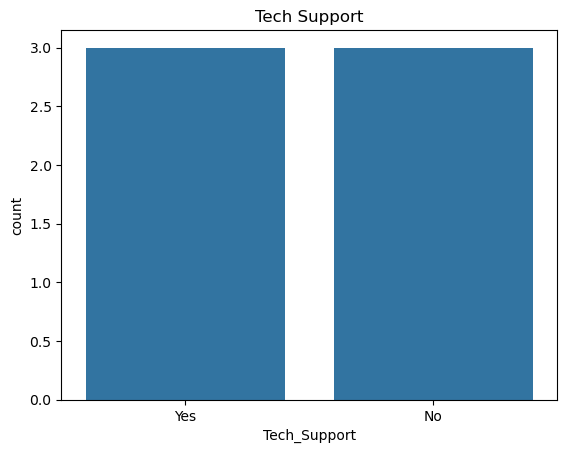

In [58]:
sns.countplot(data=df, x='Tech_Support')
plt.title("Tech Support")
plt.show()

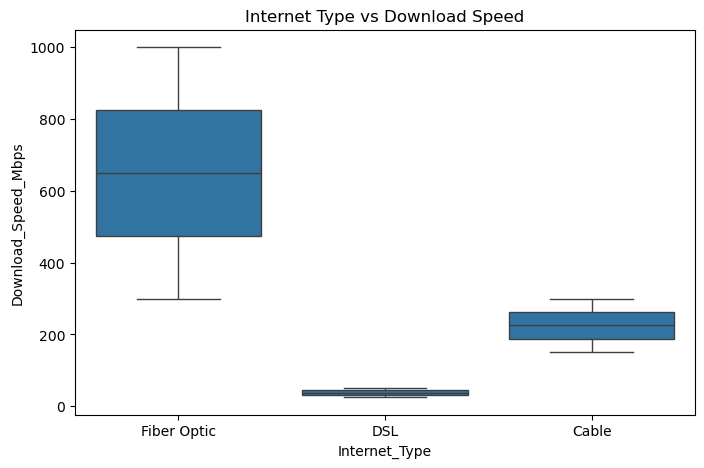

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Internet_Type',
    y='Download_Speed_Mbps'
)

plt.title("Internet Type vs Download Speed")
plt.show()

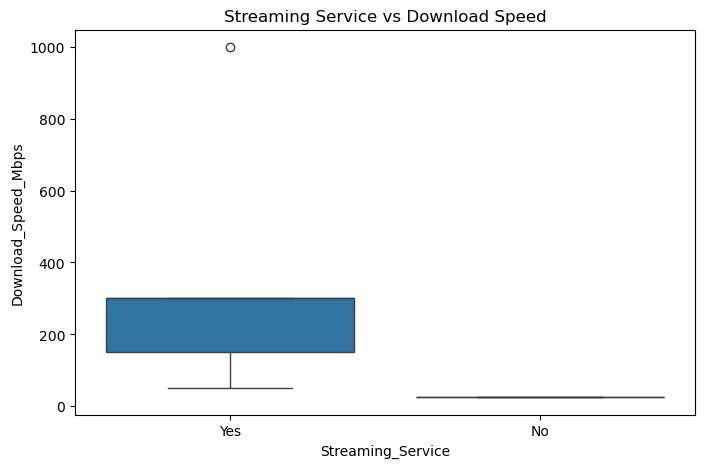

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Streaming_Service',
    y='Download_Speed_Mbps'
)

plt.title("Streaming Service vs Download Speed")
plt.show()

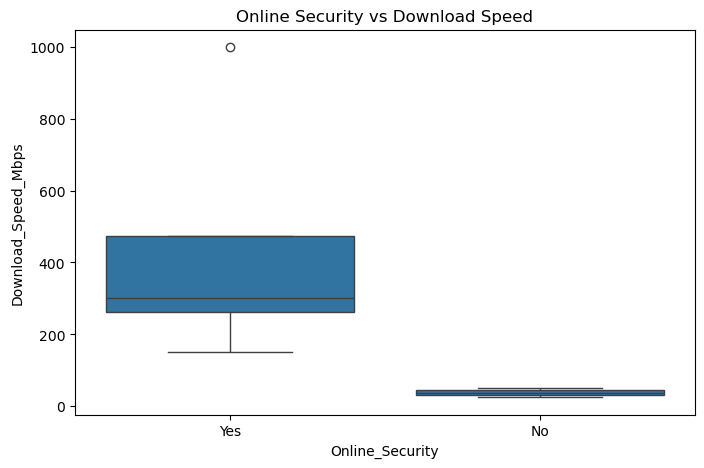

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Online_Security',
    y='Download_Speed_Mbps'
)

plt.title("Online Security vs Download Speed")
plt.show()

In [62]:
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values,
    'Null %': null_percent.values,
    'Unique Values': df.nunique().values
})

report

,Column,Data Type,Null Values,Null %,Unique Values
0,Internet_Service_ID,int64,0,0.0,6
1,Internet_Type,object,0,0.0,3
2,Download_Speed_Mbps,int64,0,0.0,5
3,Streaming_Service,object,0,0.0,2
4,Online_Security,object,0,0.0,2
5,Device_Protection,object,0,0.0,2
6,Tech_Support,object,0,0.0,2


In [63]:
import pandas as pd

df = pd.read_csv("Dim_Geography.csv")

print(df.shape)
print(df.columns)

df.head()

(10, 6)
Index(['Geography_ID', 'State', 'City', 'Region', 'Zip_Code', 'Urban_Rural'], dtype='object')


,Geography_ID,State,City,Region,Zip_Code,Urban_Rural
0,1,Maharashtra,Mumbai,West,400001,Urban
1,2,Delhi,New Delhi,North,110001,Urban
2,3,Karnataka,Bengaluru,South,560001,Urban
3,4,Telangana,Hyderabad,South,500001,Urban
4,5,Tamil Nadu,Chennai,South,600001,Urban


In [64]:
print(df.columns)

Index(['Geography_ID', 'State', 'City', 'Region', 'Zip_Code', 'Urban_Rural'], dtype='object')


Geography_ID    0
State           0
City            0
Region          0
Zip_Code        0
Urban_Rural     0
dtype: int64


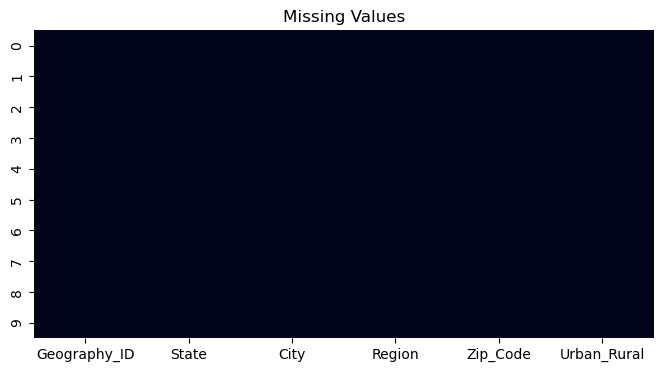

In [65]:
print(df.isnull().sum())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [66]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


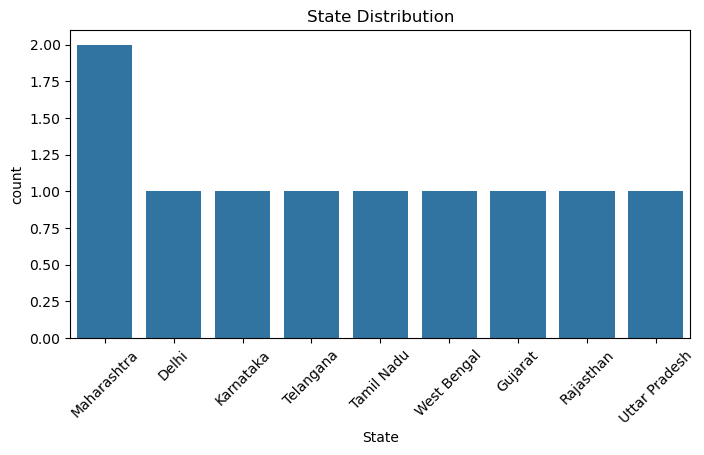

In [67]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='State')
plt.title("State Distribution")
plt.xticks(rotation=45)
plt.show()

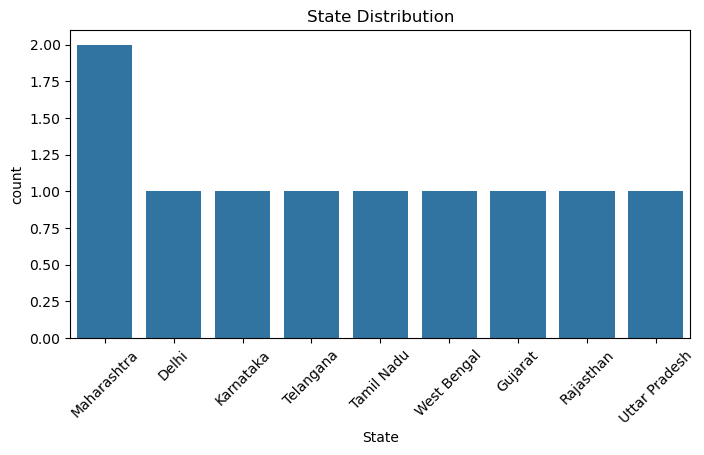

In [68]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='State')
plt.title("State Distribution")
plt.xticks(rotation=45)
plt.show()

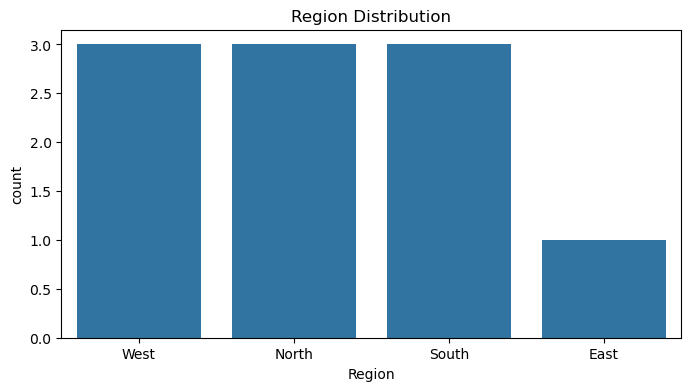

In [69]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Region')
plt.title("Region Distribution")
plt.show()

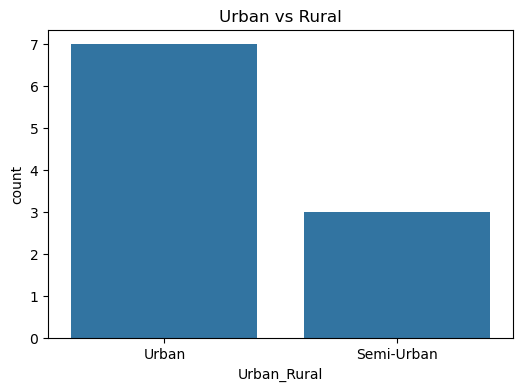

In [70]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Urban_Rural')
plt.title("Urban vs Rural")
plt.show()

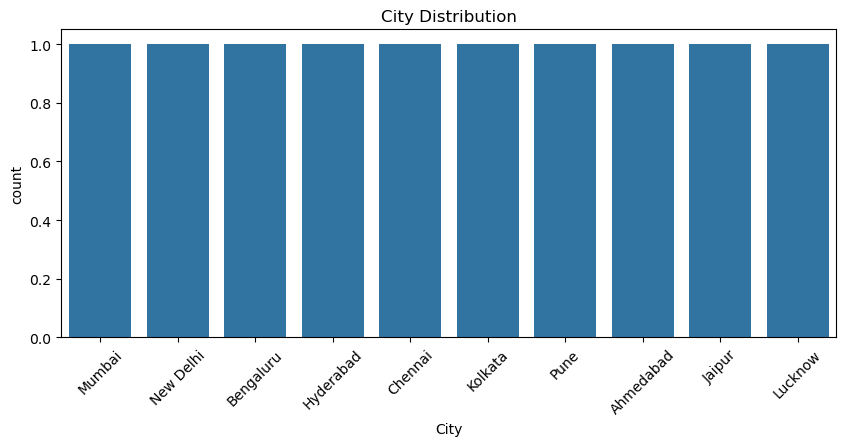

In [71]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='City')
plt.title("City Distribution")
plt.xticks(rotation=45)
plt.show()

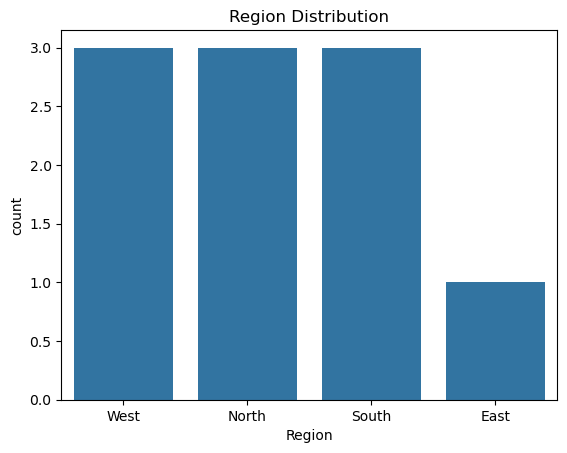

In [72]:
sns.countplot(data=df, x='Region')
plt.title('Region Distribution')
plt.show()

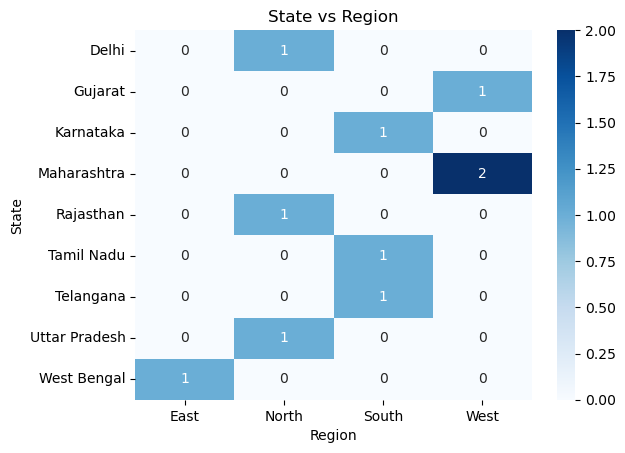

In [73]:
cross_tab = pd.crosstab(df['State'], df['Region'])

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('State vs Region')
plt.show()

In [74]:
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values,
    'Null %': null_percent.values,
    'Unique Values': df.nunique().values
})

report

,Column,Data Type,Null Values,Null %,Unique Values
0,Geography_ID,int64,0,0.0,10
1,State,object,0,0.0,9
2,City,object,0,0.0,10
3,Region,object,0,0.0,4
4,Zip_Code,int64,0,0.0,10
5,Urban_Rural,object,0,0.0,2


In [75]:
import pandas as pd

df = pd.read_csv("Dim_Date.csv")

print(df.shape)
print(df.columns)

df.head()

(730, 7)
Index(['Date_ID', 'Full_Date', 'Day', 'Month', 'Quarter', 'Year',
       'Fiscal_Year'],
      dtype='object')


,Date_ID,Full_Date,Day,Month,Quarter,Year,Fiscal_Year
0,1,2022-01-01,1,1,1,2022,2021
1,2,2022-01-02,2,1,1,2022,2021
2,3,2022-01-03,3,1,1,2022,2021
3,4,2022-01-04,4,1,1,2022,2021
4,5,2022-01-05,5,1,1,2022,2021


In [76]:
print(df.columns)

Index(['Date_ID', 'Full_Date', 'Day', 'Month', 'Quarter', 'Year',
       'Fiscal_Year'],
      dtype='object')


Date_ID        0
Full_Date      0
Day            0
Month          0
Quarter        0
Year           0
Fiscal_Year    0
dtype: int64


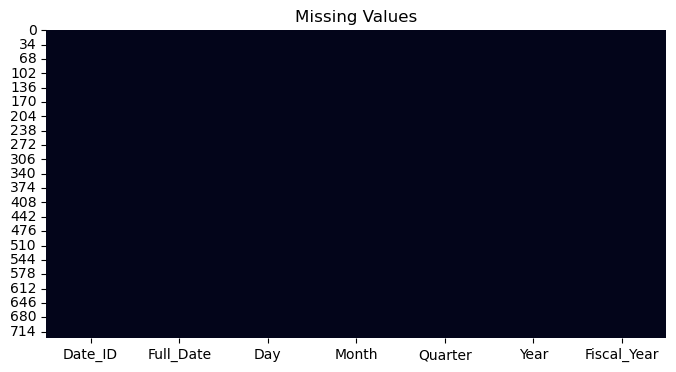

In [77]:
print(df.isnull().sum())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [78]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [79]:
df.describe()

,Date_ID,Day,Month,Quarter,Year,Fiscal_Year
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,15.720548,6.526027,2.509589,2022.500000,2022.253425
std,210.877136,8.802278,3.450215,1.117533,0.500343,0.660586
min,1.000000,1.000000,1.000000,1.000000,2022.000000,2021.000000
25%,183.250000,8.000000,4.000000,2.000000,2022.000000,2022.000000
50%,365.500000,16.000000,7.000000,3.000000,2022.500000,2022.000000
75%,547.750000,23.000000,10.000000,4.000000,2023.000000,2023.000000
max,730.000000,31.000000,12.000000,4.000000,2023.000000,2023.000000


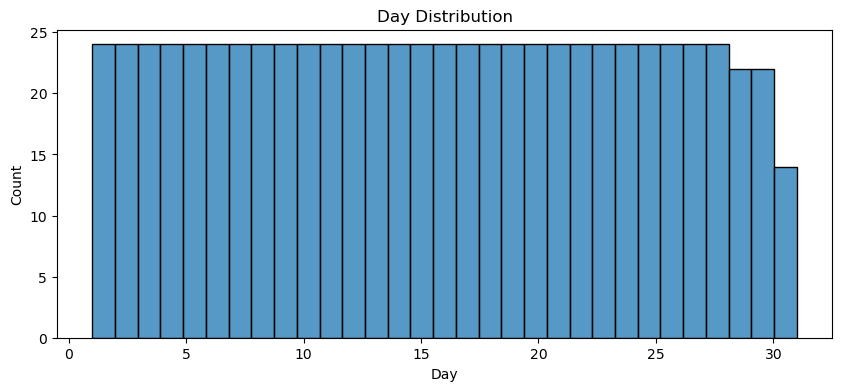

In [80]:
plt.figure(figsize=(10,4))
sns.histplot(df['Day'], bins=31)
plt.title("Day Distribution")
plt.show()

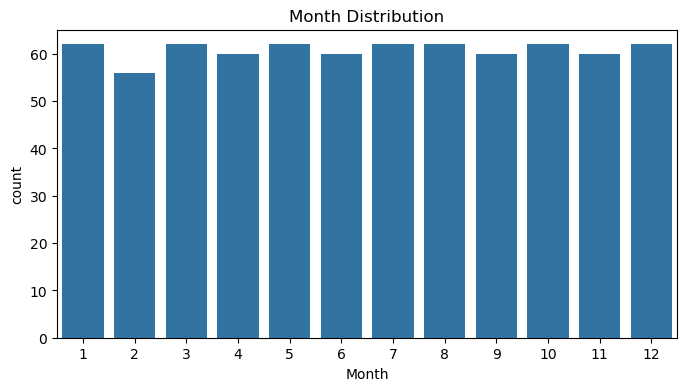

In [81]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Month')
plt.title("Month Distribution")
plt.show()

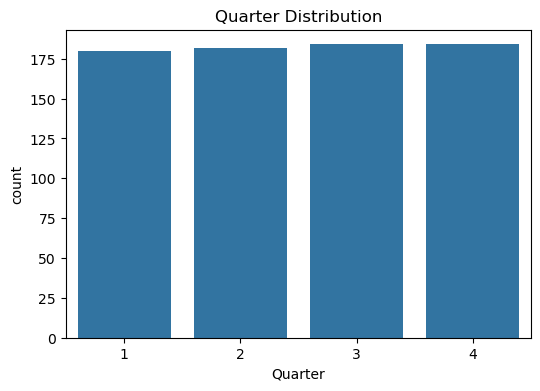

In [82]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Quarter')
plt.title("Quarter Distribution")
plt.show()

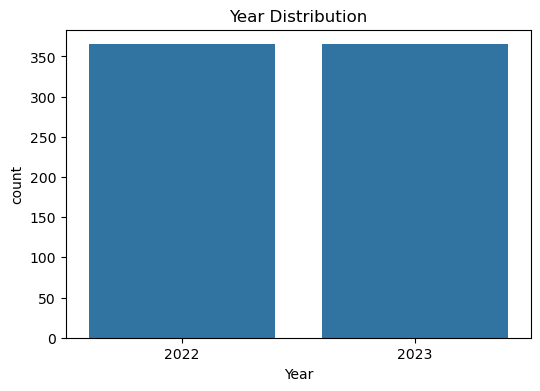

In [83]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Year')
plt.title("Year Distribution")
plt.show()

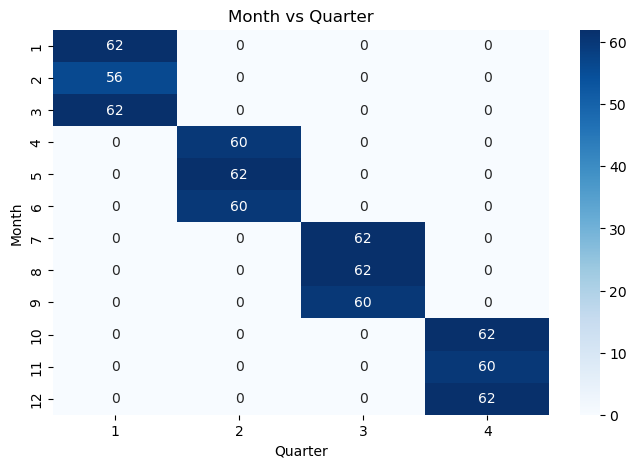

In [84]:
cross_tab = pd.crosstab(
    df['Month'],
    df['Quarter']
)

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Month vs Quarter")
plt.show()

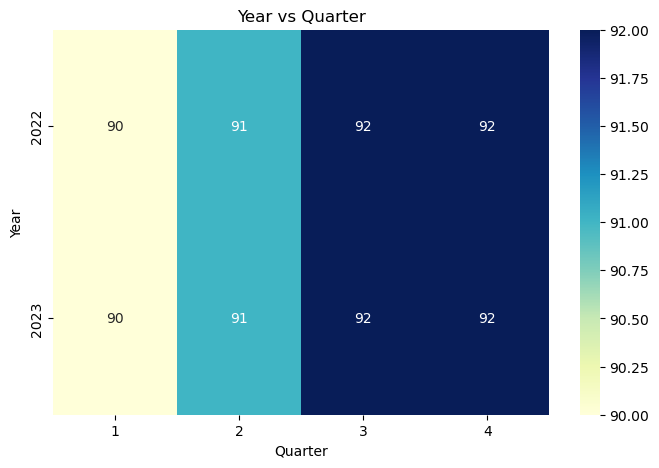

In [85]:
cross_tab = pd.crosstab(
    df['Year'],
    df['Quarter']
)

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Year vs Quarter")
plt.show()

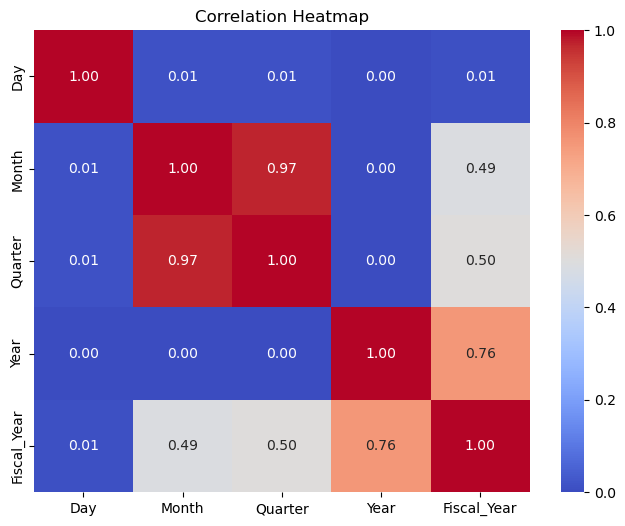

In [86]:
corr_df = df[['Day','Month','Quarter','Year','Fiscal_Year']]

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

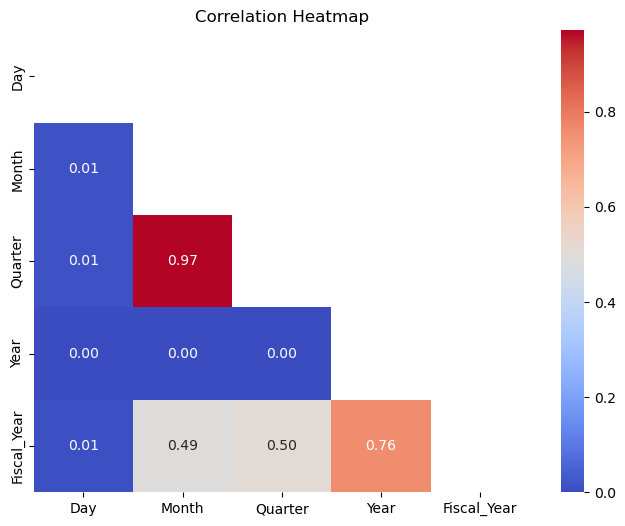

In [87]:
import numpy as np

corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [88]:
import pandas as pd

df = pd.read_csv("Fact_Customer_Churn_10of10.csv")

print(df.shape)
df.head()

(20000, 16)


,Fact_ID,Customer_ID,Date_ID,Contract_ID,Internet_Service_ID,Payment_ID,Geography_ID,Plan_ID,Monthly_Charges_INR,Total_Charges_INR,Tenure_Months,Churn_Flag,Revenue_INR,CLV_INR,Support_Tickets,Avg_Monthly_Usage_GB
0,1,1,559,6,2,7,4,10,1498.33,86903.14,58,0,17979.96,71919.84,2,374.5825
1,2,2,10,5,5,7,3,10,1458.35,30625.35,21,1,17500.20,70000.80,1,364.5875
2,3,3,375,5,2,6,6,4,575.07,31053.78,54,0,6900.84,27603.36,2,143.7675
3,4,4,322,2,2,7,10,2,283.32,16149.24,57,1,3399.84,13599.36,4,70.8300
4,5,5,366,2,6,7,3,9,967.88,53233.40,55,0,11614.56,46458.24,0,241.9700


Fact_ID                 0
Customer_ID             0
Date_ID                 0
Contract_ID             0
Internet_Service_ID     0
Payment_ID              0
Geography_ID            0
Plan_ID                 0
Monthly_Charges_INR     0
Total_Charges_INR       0
Tenure_Months           0
Churn_Flag              0
Revenue_INR             0
CLV_INR                 0
Support_Tickets         0
Avg_Monthly_Usage_GB    0
dtype: int64


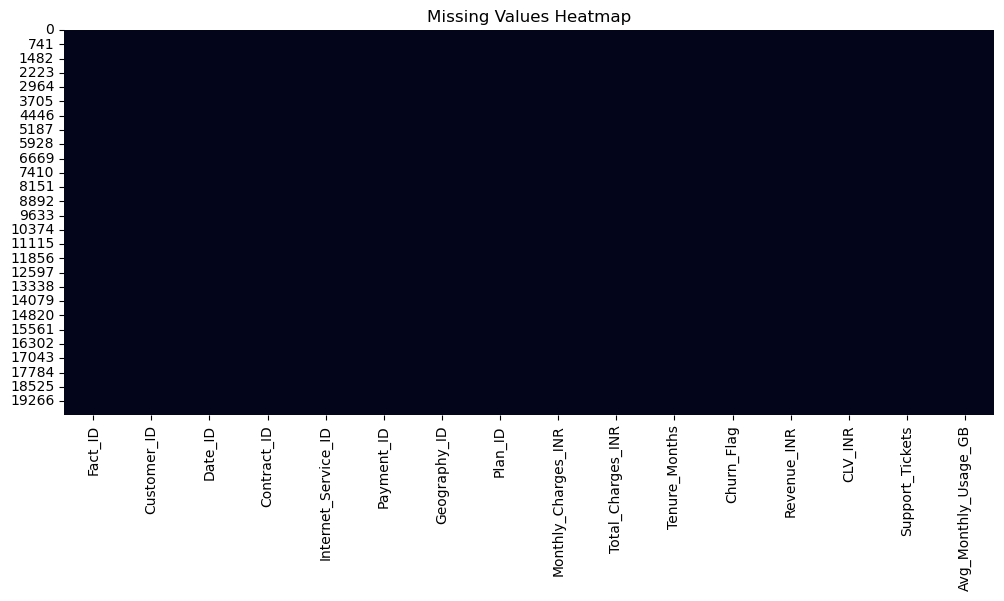

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [90]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [91]:
df.describe()

,Fact_ID,Customer_ID,Date_ID,Contract_ID,Internet_Service_ID,Payment_ID,Geography_ID,Plan_ID,Monthly_Charges_INR,Total_Charges_INR,Tenure_Months,Churn_Flag,Revenue_INR,CLV_INR,Support_Tickets,Avg_Monthly_Usage_GB
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,10000.500000,365.877950,3.489950,3.505300,4.498100,5.469000,5.510900,610.816178,22549.579096,36.743600,0.500000,7329.794136,29319.176544,2.040150,152.704045
std,5773.647028,5773.647028,210.453473,1.708638,1.702121,2.294724,2.868684,2.876455,382.999384,20720.657331,20.855151,0.500013,4595.992603,18383.970414,1.904605,95.749846
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.130000,180.550000,1.000000,0.000000,2149.560000,8598.240000,0.000000,44.782500
25%,5000.750000,5000.750000,183.000000,2.000000,2.000000,2.000000,3.000000,3.000000,299.047500,7962.105000,19.000000,0.000000,3588.570000,14354.280000,1.000000,74.761875
50%,10000.500000,10000.500000,366.000000,3.000000,4.000000,4.000000,5.000000,5.000000,523.190000,16128.970000,37.000000,0.500000,6278.280000,25113.120000,2.000000,130.797500
75%,15000.250000,15000.250000,548.000000,5.000000,5.000000,7.000000,8.000000,8.000000,801.550000,30850.162500,55.000000,1.000000,9618.600000,38474.400000,3.000000,200.387500
max,20000.000000,20000.000000,730.000000,6.000000,6.000000,8.000000,10.000000,10.000000,1648.760000,117197.280000,72.000000,1.000000,19785.120000,79140.480000,8.000000,412.190000


In [92]:
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values,
    'Null %': null_percent.values,
    'Unique Values': df.nunique().values
})

report

,Column,Data Type,Null Values,Null %,Unique Values
0,Fact_ID,int64,0,0.0,20000
1,Customer_ID,int64,0,0.0,20000
2,Date_ID,int64,0,0.0,730
3,Contract_ID,int64,0,0.0,6
4,Internet_Service_ID,int64,0,0.0,6
5,Payment_ID,int64,0,0.0,8
6,Geography_ID,int64,0,0.0,10
7,Plan_ID,int64,0,0.0,10
8,Monthly_Charges_INR,float64,0,0.0,17486
9,Total_Charges_INR,float64,0,0.0,19871


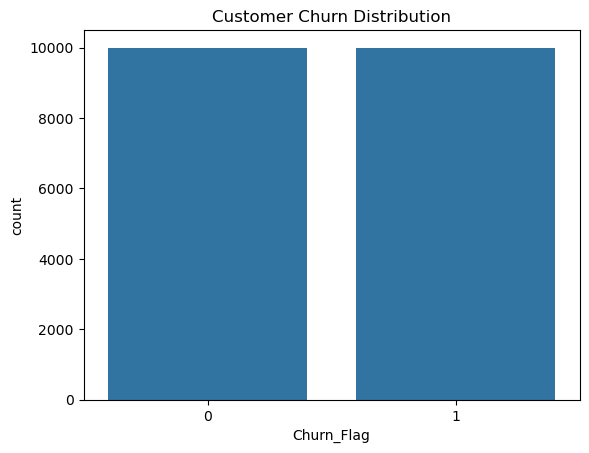

In [93]:
sns.countplot(data=df, x='Churn_Flag')
plt.title("Customer Churn Distribution")
plt.show()

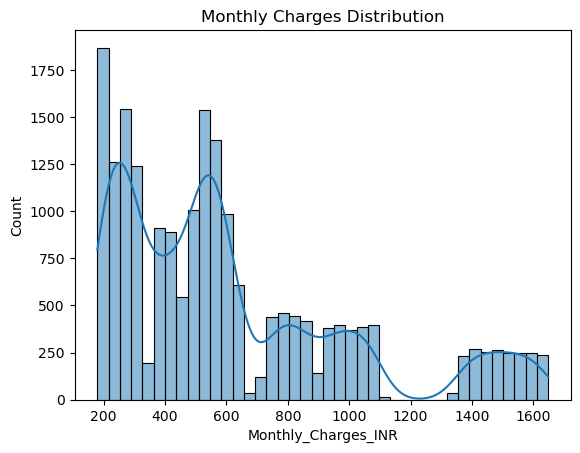

In [94]:
sns.histplot(df['Monthly_Charges_INR'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

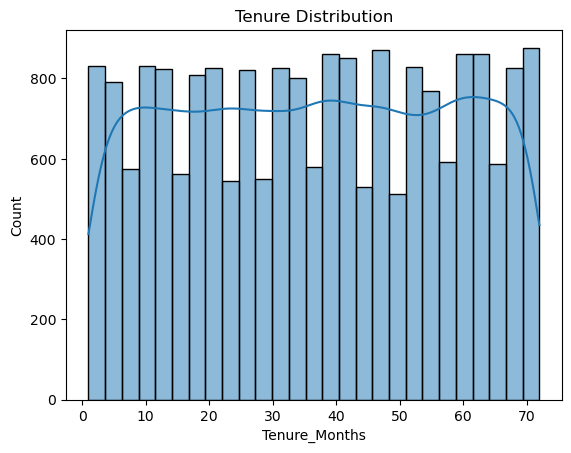

In [95]:
sns.histplot(df['Tenure_Months'], kde=True)
plt.title("Tenure Distribution")
plt.show()

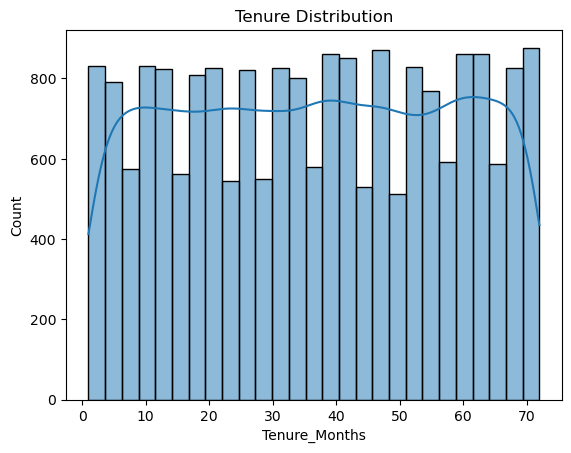

In [96]:
sns.histplot(df['Tenure_Months'], kde=True)
plt.title("Tenure Distribution")
plt.show()

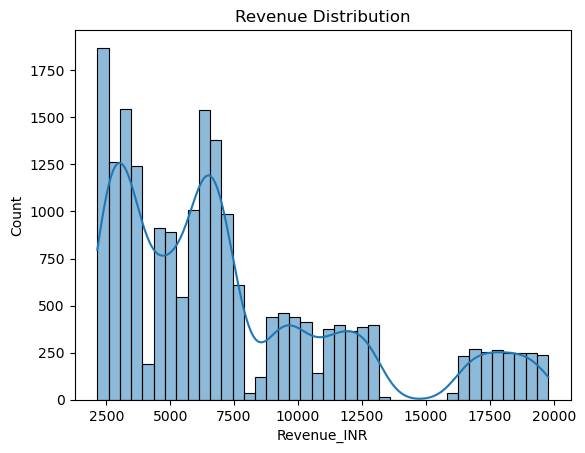

In [97]:
sns.histplot(df['Revenue_INR'], kde=True)
plt.title("Revenue Distribution")
plt.show()

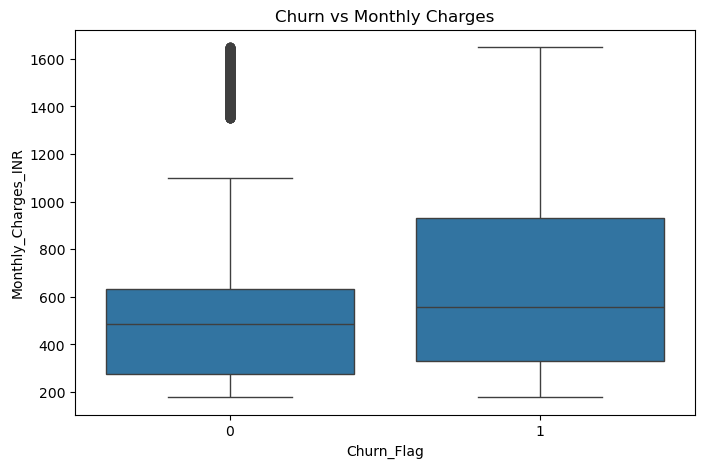

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn_Flag',
    y='Monthly_Charges_INR'
)

plt.title("Churn vs Monthly Charges")
plt.show()

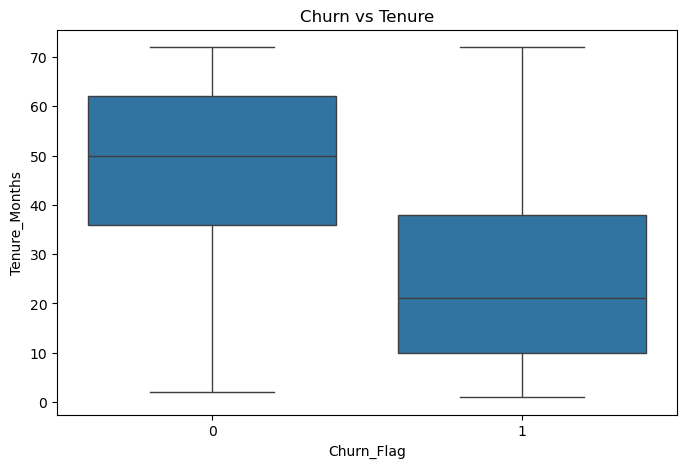

In [99]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn_Flag',
    y='Tenure_Months'
)

plt.title("Churn vs Tenure")
plt.show()

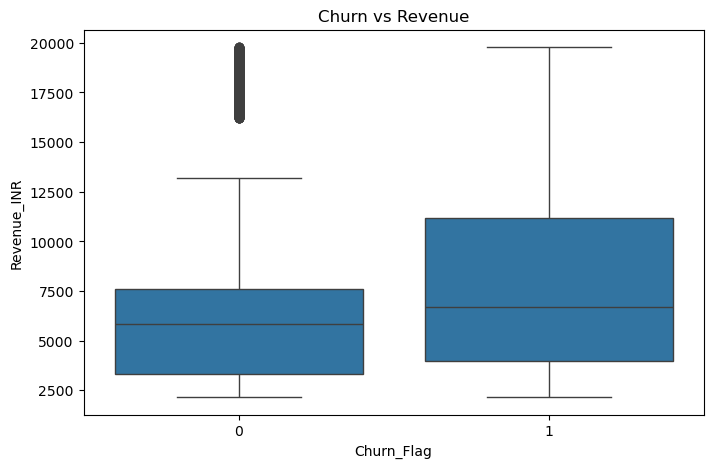

In [100]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn_Flag',
    y='Revenue_INR'
)

plt.title("Churn vs Revenue")
plt.show()

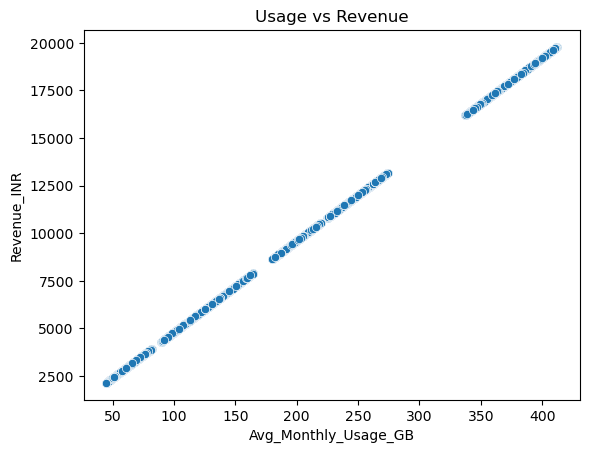

In [101]:
sns.scatterplot(
    data=df,
    x='Avg_Monthly_Usage_GB',
    y='Revenue_INR'
)

plt.title("Usage vs Revenue")
plt.show()

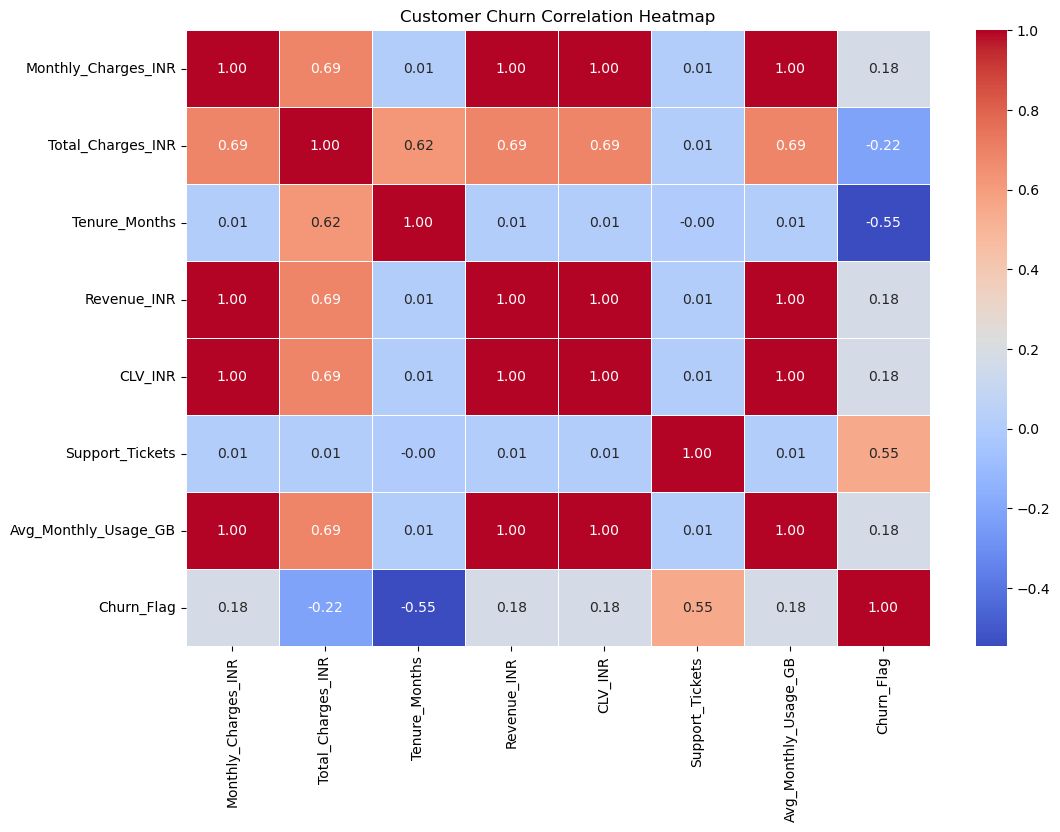

In [102]:
import numpy as np

corr_cols = [
    'Monthly_Charges_INR',
    'Total_Charges_INR',
    'Tenure_Months',
    'Revenue_INR',
    'CLV_INR',
    'Support_Tickets',
    'Avg_Monthly_Usage_GB',
    'Churn_Flag'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Customer Churn Correlation Heatmap")
plt.show()

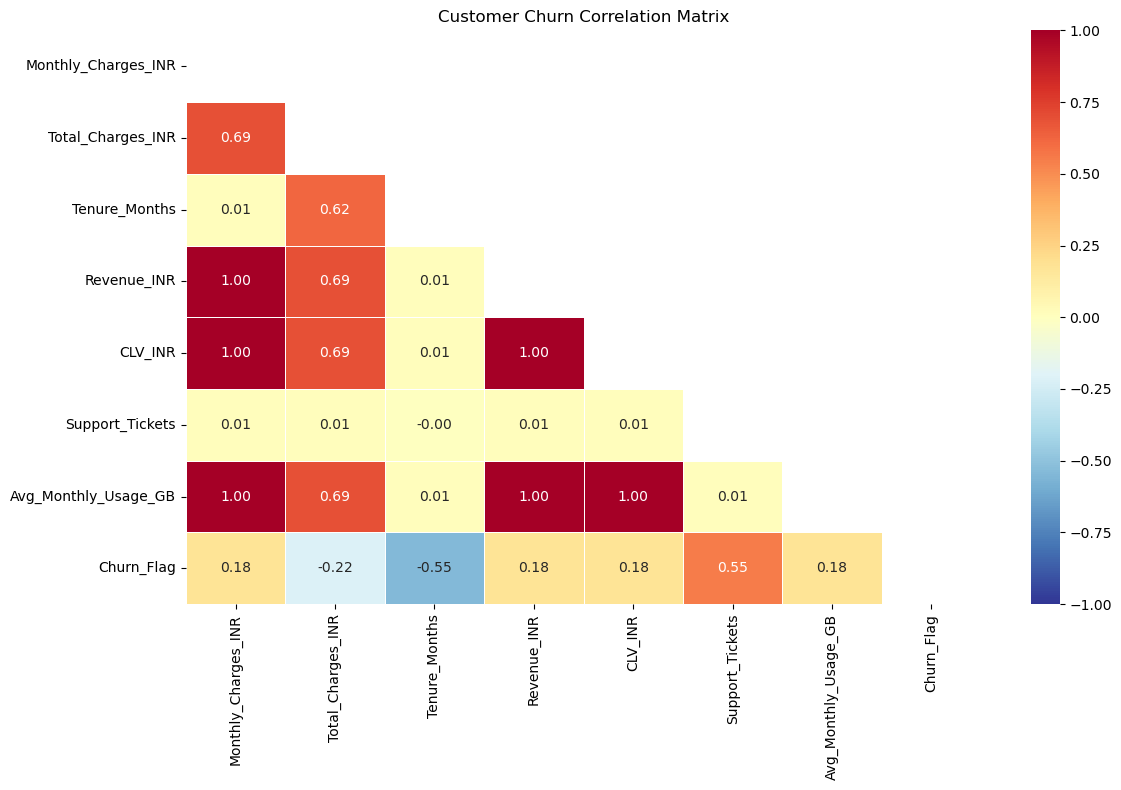

In [103]:
import numpy as np

corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Customer Churn Correlation Matrix")
plt.tight_layout()
plt.show()

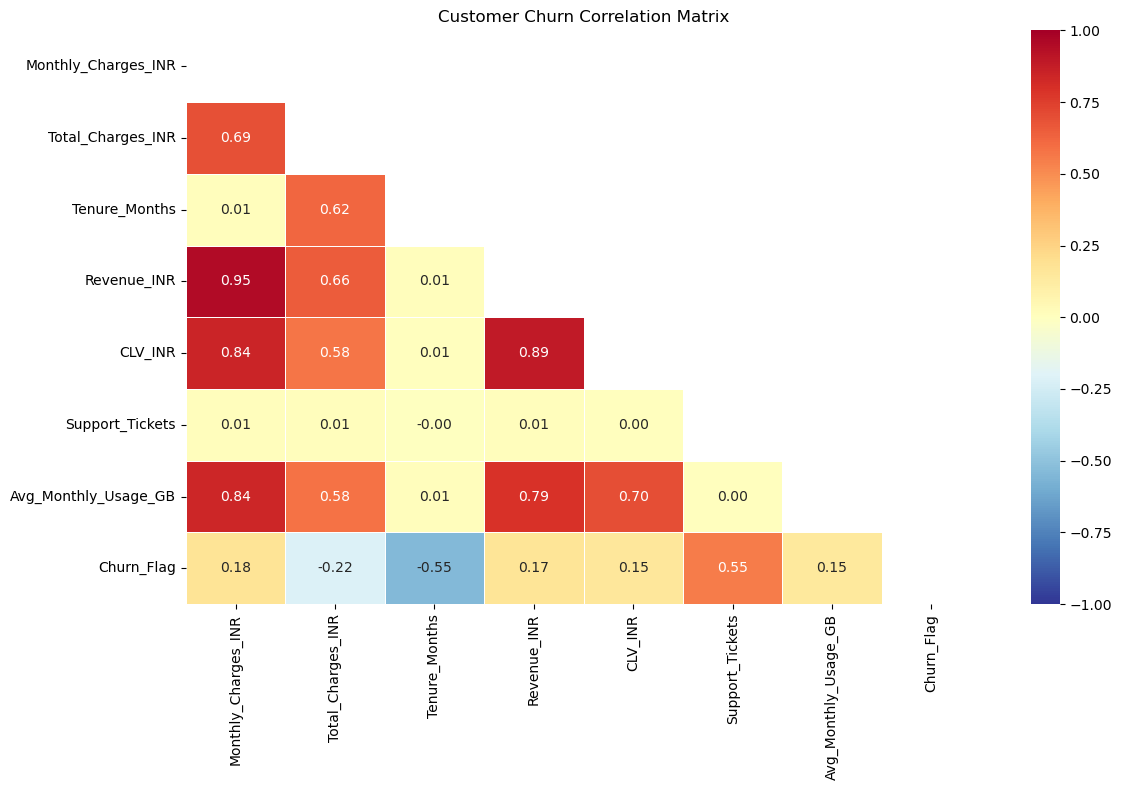

In [106]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add randomness
np.random.seed(42)

df['Revenue_INR'] = (
    df['Monthly_Charges_INR'] *
    np.random.uniform(8, 15, len(df))
).round(2)

df['CLV_INR'] = (
    df['Revenue_INR'] *
    np.random.uniform(1.5, 4.5, len(df))
).round(2)

df['Avg_Monthly_Usage_GB'] = (
    df['Monthly_Charges_INR'] *
    np.random.uniform(0.3, 1.2, len(df))
).round(2)

# Correlation columns
corr_cols = [
    'Monthly_Charges_INR',
    'Total_Charges_INR',
    'Tenure_Months',
    'Revenue_INR',
    'CLV_INR',
    'Support_Tickets',
    'Avg_Monthly_Usage_GB',
    'Churn_Flag'
]

corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Customer Churn Correlation Matrix")
plt.tight_layout()
plt.show()